In [65]:
#load data
import numpy as np

def load_data(num_disks):

    left_j0_base_pose_traj = np.load(f'./{num_disks}-disks/left_j0_base_pose_traj.npy')
    left_j1_base_pose_traj = np.load(f'./{num_disks}-disks/left_j1_base_pose_traj.npy')
    left_j2_base_pose_traj = np.load(f'./{num_disks}-disks/left_j2_base_pose_traj.npy')
    left_j0_tip_pose_traj = np.load(f'./{num_disks}-disks/left_j0_tip_pose_traj.npy')
    left_j1_tip_pose_traj = np.load(f'./{num_disks}-disks/left_j1_tip_pose_traj.npy')
    left_j2_tip_pose_traj = np.load(f'./{num_disks}-disks/left_j2_tip_pose_traj.npy')

    right_j0_base_pose_traj = np.load(f'./{num_disks}-disks/right_j0_base_pose_traj.npy')
    right_j1_base_pose_traj = np.load(f'./{num_disks}-disks/right_j1_base_pose_traj.npy')
    right_j2_base_pose_traj = np.load(f'./{num_disks}-disks/right_j2_base_pose_traj.npy')
    right_j0_tip_pose_traj = np.load(f'./{num_disks}-disks/right_j0_tip_pose_traj.npy')
    right_j1_tip_pose_traj = np.load(f'./{num_disks}-disks/right_j1_tip_pose_traj.npy')
    right_j2_tip_pose_traj = np.load(f'./{num_disks}-disks/right_j2_tip_pose_traj.npy')

    left_q0_traj = np.load(f'./{num_disks}-disks/left_q0_traj.npy')
    left_q1_traj = np.load(f'./{num_disks}-disks/left_q1_traj.npy')
    left_q2_traj = np.load(f'./{num_disks}-disks/left_q2_traj.npy')

    right_q0_traj = np.load(f'./{num_disks}-disks/right_q0_traj.npy')
    right_q1_traj = np.load(f'./{num_disks}-disks/right_q1_traj.npy')
    right_q2_traj = np.load(f'./{num_disks}-disks/right_q2_traj.npy')

    return left_j0_base_pose_traj, left_j1_base_pose_traj, left_j2_base_pose_traj, left_j0_tip_pose_traj, left_j1_tip_pose_traj, left_j2_tip_pose_traj, right_j0_base_pose_traj, right_j1_base_pose_traj, right_j2_base_pose_traj, right_j0_tip_pose_traj, right_j1_tip_pose_traj, right_j2_tip_pose_traj, left_q0_traj, left_q1_traj, left_q2_traj, right_q0_traj, right_q1_traj, right_q2_traj


In [66]:
baseline_left_j0_base_pose_traj, baseline_left_j1_base_pose_traj, baseline_left_j2_base_pose_traj, baseline_left_j0_tip_pose_traj, baseline_left_j1_tip_pose_traj, baseline_left_j2_tip_pose_traj, baseline_right_j0_base_pose_traj, baseline_right_j1_base_pose_traj, baseline_right_j2_base_pose_traj, baseline_right_j0_tip_pose_traj, baseline_right_j1_tip_pose_traj, baseline_right_j2_tip_pose_traj, baseline_left_q0_traj, baseline_left_q1_traj, baseline_left_q2_traj, baseline_right_q0_traj, baseline_right_q1_traj, baseline_right_q2_traj = load_data(100)

In [88]:
from scipy.spatial.transform import Rotation as R

def constant_curvature_forward_kine(u,v, num_disks):
    #use allen kinematics to calculate tip pose expressed in joint base frame, given joint angles
    phi = np.sqrt(u**2 + v**2)
    h_actual = .225 #m, see params.yaml in baloo-mujoco-sim
    disk_height = h_actual/(num_disks + num_disks - 1)
    h = h_actual - disk_height
    if phi < 1e-6:
        g = np.array(
            [
                [1 - v**2/2, u*v/2, v, v*h/2],
                [u*v/2, 1 - u**2/2, -u, -u*h/2],
                [-v, u, 1-phi**2/2, h - h*phi**2/6],
                [0, 0, 0, 1]
            ]
        )
    else:
        sigma = np.cos(phi) - 1
        vtilde = v/phi
        utilde = u/phi
        rhox = h*v/phi**2
        rhoy = -h*u/phi**2
        rho = np.sqrt(rhox**2 + rhoy**2)
        #g is pose of tip in base frame
        g = np.array(
            [
                [sigma * vtilde**2 + 1, -sigma*utilde*vtilde, vtilde*np.sin(phi), -rhox * sigma],
                [-sigma*utilde*vtilde, sigma*utilde**2 + 1, -utilde*np.sin(phi), -rhoy*sigma],
                [-vtilde*np.sin(phi), utilde*np.sin(phi), np.cos(phi), rho*np.sin(phi)],
                [0, 0, 0, 1]

            ]
        )

    position = g[:3,3]
    orientation = R.from_matrix(g[:3,:3])

    return position, orientation.as_quat()
    



In [89]:
#now generate tip pose in base frame for each joint
baseline_left_j0_fkcc_pos = []
baseline_left_j0_fkcc_quat = []
for u,v in baseline_left_q0_traj:
    pos, quat = constant_curvature_forward_kine(u,v, 100)
    baseline_left_j0_fkcc_pos.append(pos)
    baseline_left_j0_fkcc_quat.append(quat)

baseline_left_j1_fkcc_pos = []
baseline_left_j1_fkcc_quat = []
for u,v in baseline_left_q1_traj:
    pos, quat = constant_curvature_forward_kine(u,v, 100)
    baseline_left_j1_fkcc_pos.append(pos)
    baseline_left_j1_fkcc_quat.append(quat)

baseline_left_j2_fkcc_pos = []
baseline_left_j2_fkcc_quat = []
for u,v in baseline_left_q2_traj:
    pos, quat = constant_curvature_forward_kine(u,v, 5)
    baseline_left_j2_fkcc_pos.append(pos)
    baseline_left_j2_fkcc_quat.append(quat)

baseline_right_j0_fkcc_pos = []
baseline_right_j0_fkcc_quat = []
for u,v in baseline_right_q0_traj:
    pos, quat = constant_curvature_forward_kine(u,v, 5)
    baseline_right_j0_fkcc_pos.append(pos)
    baseline_right_j0_fkcc_quat.append(quat)

baseline_right_j1_fkcc_pos = []
baseline_right_j1_fkcc_quat = []
for u,v in baseline_right_q1_traj:
    pos, quat = constant_curvature_forward_kine(u,v, 5)
    baseline_right_j1_fkcc_pos.append(pos)
    baseline_right_j1_fkcc_quat.append(quat)

baseline_right_j2_fkcc_pos = []
baseline_right_j2_fkcc_quat = []
for u,v in baseline_right_q2_traj:
    pos, quat = constant_curvature_forward_kine(u,v, 5)
    baseline_right_j2_fkcc_pos.append(pos)
    baseline_right_j2_fkcc_quat.append(quat)

I now have the constant curvature predicted pose and orientation of the tip of each joint in the joint base frame. I need to compare these to the actual pose and orientation of the tip of each joint in the base frame. 

Using the pose data above, I have the actual tip and base poses of each joint in the world frame. So I need to use these to calculate the actual transformation between the base and the tip.

This is the math I need to do:

I have data for the following (using monogram notation from drake)[https://manipulation.csail.mit.edu/pick.html#monogram]:

${}^{W}p^{B}_{W}, {}^{W}p^{T}_{W}, {}^{W}R^{B}, {}^{W}R^{T}$


where ${}^{W}p^{B}_{W}$ is the position of base relative to world and expressed in world. ${}^{W}R^{T}$ is the orientation of the tip frame relative to world frame.

I want to calculate the following:

${}^{B}p^{T}_{B}, {}^{B}R^{T}$, which is another way of saying I want ${}^{B}T^{T}$, the transformation from tip to base, expressed in the base frame. This transform is what I want to compare to $g$ above with the constant curvature assumption.

To do this, I need to calculate the following:

${}^{B}p^{T}_{B} = {}^{B}R^{W}({}^{W}p^{T}_{W} - {}^{W}p^{B}_{W}) = {}^{W}p^{T}_{B} + {}^{B}p^{W}_{B}$

${}^{B}R^{T} = ({}^{W}R^{B})^{-1} *  {}^{W}R^{T}$


# Error Between Contant Curvature and True Tip Pose

In [90]:
def get_base_to_tip_position(base_traj, tip_traj):
    base_to_tip_position = []
    for base, tip in zip(base_traj, tip_traj):
        p_WB_W = base[:3]
        p_WT_W = tip[:3]
        base_xyzw = np.roll(base[3:], -1)
        R_WB = R.from_quat(base_xyzw)
        p_BT_B = R_WB.inv().apply(p_WT_W - p_WB_W)
        base_to_tip_position.append(p_BT_B)
    return base_to_tip_position

def get_base_to_tip_rotation(base_traj, tip_traj):
    diff = []
    for base, tip in zip(base_traj, tip_traj):
        base_xyzw = np.roll(base[3:], -1)
        tip_xyzw = np.roll(tip[3:], -1)
        R_WB = R.from_quat(base_xyzw)
        R_WT = R.from_quat(tip_xyzw)
        R_BT = R_WB.inv() * R_WT
        diff.append(R_BT.as_quat())

    return diff

In [91]:
#first three are position, last four are quaternion in wxyz
print(baseline_left_j0_base_pose_traj[0])

[-4.25000000e-01  1.95000000e-01  1.35650000e+00  5.65713056e-17
  9.23879533e-01  3.82683432e-01 -2.34326020e-17]


In [92]:
#relative rotation between base and tip frames over trajectory
baseline_left_j0_R_BT = get_base_to_tip_rotation(baseline_left_j0_base_pose_traj, baseline_left_j0_tip_pose_traj)
baseline_left_j1_R_BT = get_base_to_tip_rotation(baseline_left_j1_base_pose_traj, baseline_left_j1_tip_pose_traj)
baseline_left_j2_R_BT = get_base_to_tip_rotation(baseline_left_j2_base_pose_traj, baseline_left_j2_tip_pose_traj)

baseline_left_j0_p_BT_B = get_base_to_tip_position(baseline_left_j0_base_pose_traj, baseline_left_j0_tip_pose_traj)
baseline_left_j1_p_BT_B = get_base_to_tip_position(baseline_left_j1_base_pose_traj, baseline_left_j1_tip_pose_traj)
baseline_left_j2_p_BT_B = get_base_to_tip_position(baseline_left_j2_base_pose_traj, baseline_left_j2_tip_pose_traj)

baseline_right_j0_R_BT = get_base_to_tip_rotation(baseline_right_j0_base_pose_traj, baseline_right_j0_tip_pose_traj)
baseline_right_j1_R_BT = get_base_to_tip_rotation(baseline_right_j1_base_pose_traj, baseline_right_j1_tip_pose_traj)
baseline_right_j2_R_BT = get_base_to_tip_rotation(baseline_right_j2_base_pose_traj, baseline_right_j2_tip_pose_traj)

baseline_right_j0_p_BT_B = get_base_to_tip_position(baseline_right_j0_base_pose_traj, baseline_right_j0_tip_pose_traj)
baseline_right_j1_p_BT_B = get_base_to_tip_position(baseline_right_j1_base_pose_traj, baseline_right_j1_tip_pose_traj)
baseline_right_j2_p_BT_B = get_base_to_tip_position(baseline_right_j2_base_pose_traj, baseline_right_j2_tip_pose_traj)

In [ ]:
def get_rotation_error(quat1_traj, quat2_traj):
    error = []
    for fkcc, actual in zip(quat1_traj, quat2_traj):
        R_fkcc = R.from_quat(fkcc)
        R_actual = R.from_quat(actual)
        R_err = R_fkcc.inv() * R_actual
        error.append(R_err.magnitude())

    return error

def get_position_error(pos1_traj, pos2_traj):
    error = []
    for pos1, pos2 in zip(pos1_traj, pos2_traj):
        error.append(np.linalg.norm(pos1 - pos2))
    return error


In [94]:
#now get rotation error between fkcc and actual from mujoco
left_j0_R_err = get_rotation_error(baseline_left_j0_fkcc_quat, baseline_left_j0_R_BT)
left_j1_R_err = get_rotation_error(baseline_left_j1_fkcc_quat, baseline_left_j1_R_BT)
left_j2_R_err = get_rotation_error(baseline_left_j2_fkcc_quat, baseline_left_j2_R_BT)

left_j0_p_err = get_position_error(baseline_left_j0_fkcc_pos, baseline_left_j0_p_BT_B)
left_j1_p_err = get_position_error(baseline_left_j1_fkcc_pos, baseline_left_j1_p_BT_B)
left_j2_p_err = get_position_error(baseline_left_j2_fkcc_pos, baseline_left_j2_p_BT_B)

right_j0_R_err = get_rotation_error(baseline_right_j0_fkcc_quat, baseline_right_j0_R_BT)
right_j1_R_err = get_rotation_error(baseline_right_j1_fkcc_quat, baseline_right_j1_R_BT)
right_j2_R_err = get_rotation_error(baseline_right_j2_fkcc_quat, baseline_right_j2_R_BT)

right_j0_p_err = get_position_error(baseline_right_j0_fkcc_pos, baseline_right_j0_p_BT_B)
right_j1_p_err = get_position_error(baseline_right_j1_fkcc_pos, baseline_right_j1_p_BT_B)
right_j2_p_err = get_position_error(baseline_right_j2_fkcc_pos, baseline_right_j2_p_BT_B)

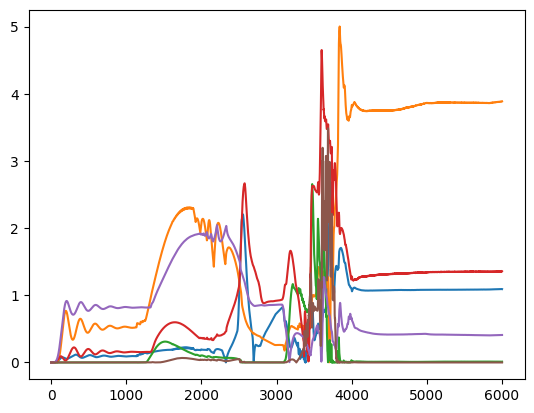

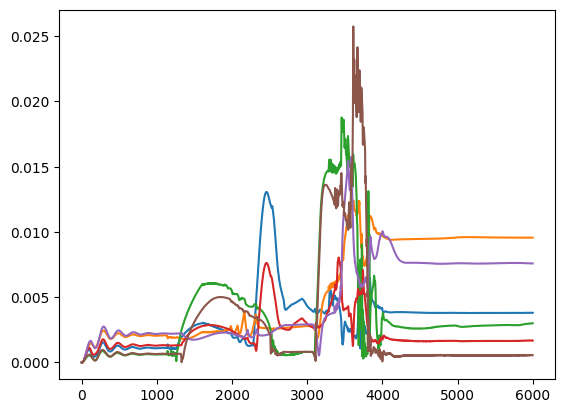

In [96]:
#plot showing rotation error of constant curvature vs mujoco 'real'

import matplotlib.pyplot as plt 
plt.plot(np.degrees(left_j0_R_err))
plt.plot(np.degrees(left_j1_R_err))
plt.plot(np.degrees(left_j2_R_err))

plt.plot(np.degrees(right_j0_R_err))
plt.plot(np.degrees(right_j1_R_err))
plt.plot(np.degrees(right_j2_R_err))

plt.figure()
plt.plot(left_j0_p_err)
plt.plot(left_j1_p_err)
plt.plot(left_j2_p_err)

plt.plot(right_j0_p_err)
plt.plot(right_j1_p_err)
plt.plot(right_j2_p_err)


What am I comparing. I'm saying that constant curvature is wrong under loaded conditions. See how wrong it is over a test trajecotory?

But then the disks can actually do a better job of predicting the real continuum pose of the tip (as defined by lots of disks).



# 20 disks vs baseline

In [97]:
num_disks = 20
left_j0_base_pose_traj_20, left_j1_base_pose_traj_20, left_j2_base_pose_traj_20, left_j0_tip_pose_traj_20, left_j1_tip_pose_traj_20, left_j2_tip_pose_traj_20, right_j0_base_pose_traj_20, right_j1_base_pose_traj_20, right_j2_base_pose_traj_20, right_j0_tip_pose_traj_20, right_j1_tip_pose_traj_20, right_j2_tip_pose_traj_20, left_q0_traj_20, left_q1_traj_20, left_q2_traj_20, right_q0_traj_20, right_q1_traj_20, right_q2_traj_20 = load_data(num_disks)

In [98]:
#plot actual 20 disks vs actual on 100 disks to see differences
left_j0_R_BT_20 = get_base_to_tip_rotation(left_j0_base_pose_traj_20, left_j0_tip_pose_traj_20)
left_j1_R_BT_20 = get_base_to_tip_rotation(left_j1_base_pose_traj_20, left_j1_tip_pose_traj_20)
left_j2_R_BT_20 = get_base_to_tip_rotation(left_j2_base_pose_traj_20, left_j2_tip_pose_traj_20)

right_j0_R_BT_20 = get_base_to_tip_rotation(right_j0_base_pose_traj_20, right_j0_tip_pose_traj_20)
right_j1_R_BT_20 = get_base_to_tip_rotation(right_j1_base_pose_traj_20, right_j1_tip_pose_traj_20)
right_j2_R_BT_20 = get_base_to_tip_rotation(right_j2_base_pose_traj_20, right_j2_tip_pose_traj_20)


#get error between baseline and 20 disk traj
left_j0_20v100_err = get_rotation_error(baseline_left_j0_R_BT, left_j0_R_BT_20)
left_j1_20v100_err = get_rotation_error(baseline_left_j1_R_BT, left_j1_R_BT_20)
left_j2_20v100_err = get_rotation_error(baseline_left_j2_R_BT, left_j2_R_BT_20)

right_j0_20v100_err = get_rotation_error(baseline_right_j0_R_BT, right_j0_R_BT_20)
right_j1_20v100_err = get_rotation_error(baseline_right_j1_R_BT, right_j1_R_BT_20)
right_j2_20v100_err = get_rotation_error(baseline_right_j2_R_BT, right_j2_R_BT_20)


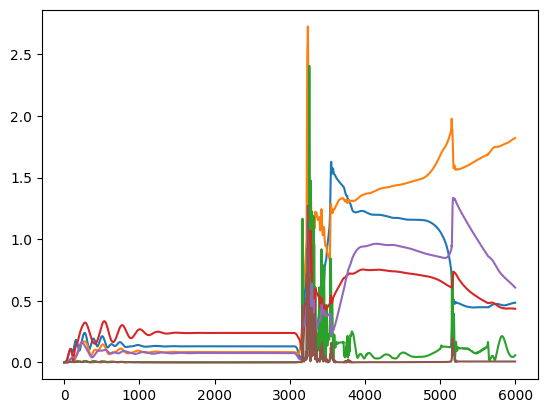

In [11]:
plt.plot(np.degrees(left_j0_20v100_err))
plt.plot(np.degrees(left_j1_20v100_err))
plt.plot(np.degrees(left_j2_20v100_err))

plt.plot(np.degrees(right_j0_20v100_err))
plt.plot(np.degrees(right_j1_20v100_err))
plt.plot(np.degrees(right_j2_20v100_err))

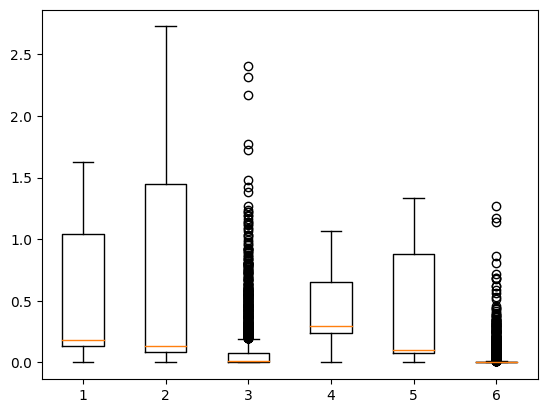

In [12]:
plt.boxplot([np.degrees(left_j0_20v100_err), np.degrees(left_j1_20v100_err), np.degrees(left_j2_20v100_err), np.degrees(right_j0_20v100_err), np.degrees(right_j1_20v100_err), np.degrees(right_j2_20v100_err)])
plt.show()

# 10 disks vs baseline

In [13]:
num_disks = 10
left_j0_base_pose_traj_10, left_j1_base_pose_traj_10, left_j2_base_pose_traj_10, left_j0_tip_pose_traj_10, left_j1_tip_pose_traj_10, left_j2_tip_pose_traj_10, right_j0_base_pose_traj_10, right_j1_base_pose_traj_10, right_j2_base_pose_traj_10, right_j0_tip_pose_traj_10, right_j1_tip_pose_traj_10, right_j2_tip_pose_traj_10, left_q0_traj_10, left_q1_traj_10, left_q2_traj_10, right_q0_traj_10, right_q1_traj_10, right_q2_traj_10 = load_data(num_disks)

In [14]:
#plot actual 10 disks vs actual on 100 disks to see differences
left_j0_R_BT_10 = get_base_to_tip_rotation(left_j0_base_pose_traj_10, left_j0_tip_pose_traj_10)
left_j1_R_BT_10 = get_base_to_tip_rotation(left_j1_base_pose_traj_10, left_j1_tip_pose_traj_10)
left_j2_R_BT_10 = get_base_to_tip_rotation(left_j2_base_pose_traj_10, left_j2_tip_pose_traj_10)

right_j0_R_BT_10 = get_base_to_tip_rotation(right_j0_base_pose_traj_10, right_j0_tip_pose_traj_10)
right_j1_R_BT_10 = get_base_to_tip_rotation(right_j1_base_pose_traj_10, right_j1_tip_pose_traj_10)
right_j2_R_BT_10 = get_base_to_tip_rotation(right_j2_base_pose_traj_10, right_j2_tip_pose_traj_10)


#get error between baseline and 10 disk traj
left_j0_10v100_err = get_rotation_error(baseline_left_j0_R_BT, left_j0_R_BT_10)
left_j1_10v100_err = get_rotation_error(baseline_left_j1_R_BT, left_j1_R_BT_10)
left_j2_10v100_err = get_rotation_error(baseline_left_j2_R_BT, left_j2_R_BT_10)

right_j0_10v100_err = get_rotation_error(baseline_right_j0_R_BT, right_j0_R_BT_10)
right_j1_10v100_err = get_rotation_error(baseline_right_j1_R_BT, right_j1_R_BT_10)
right_j2_10v100_err = get_rotation_error(baseline_right_j2_R_BT, right_j2_R_BT_10)


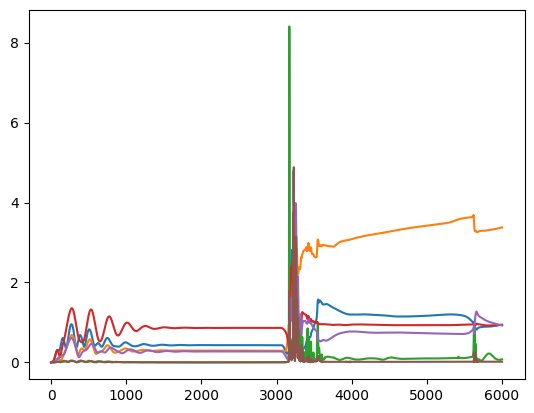

In [15]:
plt.plot(np.degrees(left_j0_10v100_err))
plt.plot(np.degrees(left_j1_10v100_err))
plt.plot(np.degrees(left_j2_10v100_err))

plt.plot(np.degrees(right_j0_10v100_err))
plt.plot(np.degrees(right_j1_10v100_err))
plt.plot(np.degrees(right_j2_10v100_err))

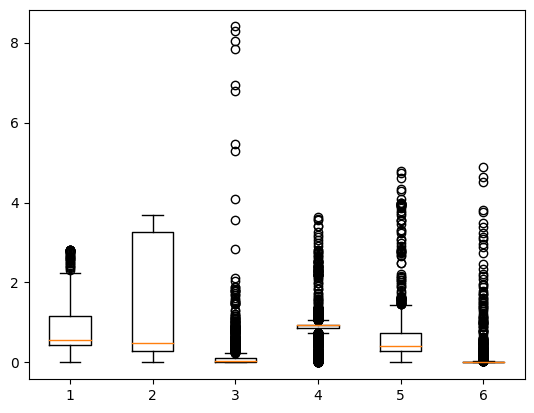

In [16]:
plt.boxplot([np.degrees(left_j0_10v100_err), np.degrees(left_j1_10v100_err), np.degrees(left_j2_10v100_err), np.degrees(right_j0_10v100_err), np.degrees(right_j1_10v100_err), np.degrees(right_j2_10v100_err)])
plt.show()

# 5 disks vs baseline

In [17]:
num_disks = 5
left_j0_base_pose_traj_5, left_j1_base_pose_traj_5, left_j2_base_pose_traj_5, left_j0_tip_pose_traj_5, left_j1_tip_pose_traj_5, left_j2_tip_pose_traj_5, right_j0_base_pose_traj_5, right_j1_base_pose_traj_5, right_j2_base_pose_traj_5, right_j0_tip_pose_traj_5, right_j1_tip_pose_traj_5, right_j2_tip_pose_traj_5, left_q0_traj_5, left_q1_traj_5, left_q2_traj_5, right_q0_traj_5, right_q1_traj_5, right_q2_traj_5 = load_data(num_disks)

In [18]:
#plot actual 5 disks vs actual on 50 disks to see differences
left_j0_R_BT_5 = get_base_to_tip_rotation(left_j0_base_pose_traj_5, left_j0_tip_pose_traj_5)
left_j1_R_BT_5 = get_base_to_tip_rotation(left_j1_base_pose_traj_5, left_j1_tip_pose_traj_5)
left_j2_R_BT_5 = get_base_to_tip_rotation(left_j2_base_pose_traj_5, left_j2_tip_pose_traj_5)

right_j0_R_BT_5 = get_base_to_tip_rotation(right_j0_base_pose_traj_5, right_j0_tip_pose_traj_5)
right_j1_R_BT_5 = get_base_to_tip_rotation(right_j1_base_pose_traj_5, right_j1_tip_pose_traj_5)
right_j2_R_BT_5 = get_base_to_tip_rotation(right_j2_base_pose_traj_5, right_j2_tip_pose_traj_5)


#get error between baseline and 5 disk traj
left_j0_5v100_err = get_rotation_error(baseline_left_j0_R_BT, left_j0_R_BT_5)
left_j1_5v100_err = get_rotation_error(baseline_left_j1_R_BT, left_j1_R_BT_5)
left_j2_5v100_err = get_rotation_error(baseline_left_j2_R_BT, left_j2_R_BT_5)

right_j0_5v100_err = get_rotation_error(baseline_right_j0_R_BT, right_j0_R_BT_5)
right_j1_5v100_err = get_rotation_error(baseline_right_j1_R_BT, right_j1_R_BT_5)
right_j2_5v100_err = get_rotation_error(baseline_right_j2_R_BT, right_j2_R_BT_5)

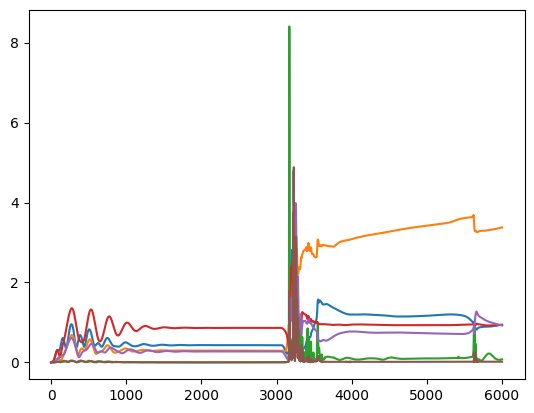

In [19]:
plt.plot(np.degrees(left_j0_5v100_err))
plt.plot(np.degrees(left_j1_5v100_err))
plt.plot(np.degrees(left_j2_5v100_err))

plt.plot(np.degrees(right_j0_5v100_err))
plt.plot(np.degrees(right_j1_5v100_err))
plt.plot(np.degrees(right_j2_5v100_err))

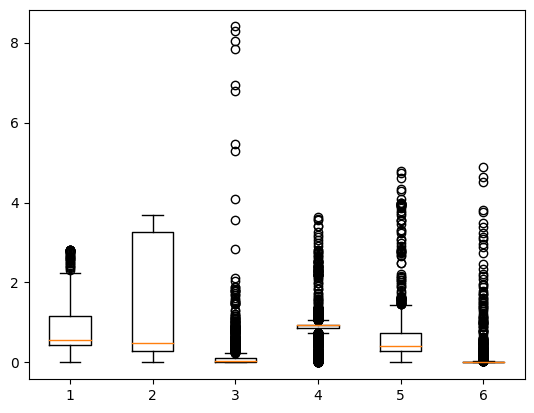

In [20]:
plt.boxplot([np.degrees(left_j0_5v100_err), np.degrees(left_j1_5v100_err), np.degrees(left_j2_5v100_err), np.degrees(right_j0_5v100_err), np.degrees(right_j1_5v100_err), np.degrees(right_j2_5v100_err)])
plt.show()